In [ ]:
!pip install chemprop==1.6.1
!pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1
!pip install rdkit

!pip install shap

!pip install scikit-learn==1.3.2

!pip install rdkit==2024.9.5
!pip install pandas==2.2.2
!pip install numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 817.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 93.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 102.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 855.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.3/34.3 MB 39.4 MB/s eta 0:00:00
  Attempting uninstall: rdkit
    Found existing installation: rdkit 2026.3.2
    Uninstalling rdkit-2026.3.2:
      Successfully uninstalled rdkit-2026.3.2


In [ ]:
import sys
sys.path.append(".")

import pandas as pd
import chemprop
import numpy as np
import torch
import random
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import spearmanr, sem

# ============================================================
# 1️⃣  Set seeds for reproducibility
# ============================================================
MASTER_SEED = 42
random.seed(MASTER_SEED)
np.random.seed(MASTER_SEED)
torch.manual_seed(MASTER_SEED)
torch.cuda.manual_seed_all(MASTER_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ============================================================
# 2️⃣  File paths
# ============================================================
source_excel_path = '20240813_comprehensive_data(2).xlsx'
combined_csv_path = 'combined_full_MSM_dataset.csv'
train_pred_path = 'full_train_emb_MSM.csv'
checkpoint_dir = 'full_MSM_checkpoints'

# ============================================================
# 3️⃣  Combine datasets from multiple sheets
# ============================================================
sheet_names_to_combine = ['smiles_react_perm_1200', 'smiles_react_perm_380', 'smiles_react_perm_40']
combined_df_list = []

for sheet in sheet_names_to_combine:
    df = pd.read_excel(source_excel_path, sheet_name=sheet, usecols=['Smile', 'msm_perm'])
    df = df.dropna(subset=['Smile', 'msm_perm'])
    combined_df_list.append(df)

combined_full_df = pd.concat(combined_df_list, ignore_index=True)
combined_full_df.to_csv(combined_csv_path, index=False)
print(f"✅ Combined dataset created with {len(combined_full_df)} rows.")

# ============================================================
# 4️⃣  Chemprop model training and fingerprint extraction
# ============================================================
arguments = [
    '--data_path', combined_csv_path,
    '--dataset_type', 'regression',
    '--save_dir', checkpoint_dir,
    '--ffn_hidden_size', '300',
    '--epochs', '30',
    '--save_smiles_splits',
    '--smiles_columns', 'Smile',
    '--target_columns', 'msm_perm',
    '--split_type', 'scaffold_balanced',
    '--hidden_size', '300',
    '--num_folds', '1',
    '--pytorch_seed', str(MASTER_SEED),
    '--seed', str(MASTER_SEED)
]

args = chemprop.args.TrainArgs().parse_args(arguments)
chemprop.train.cross_validate(args=args, train_func=chemprop.train.run_training)

# Extract embeddings
args = chemprop.args.FingerprintArgs().parse_args([
    '--test_path', combined_csv_path,
    '--preds_path', train_pred_path,
    '--checkpoint_dir', checkpoint_dir,
    '--smiles_columns', 'Smile',
    '--fingerprint_type', 'MPN'
])
chemprop.train.molecule_fingerprint.molecule_fingerprint(args=args)

# ============================================================
# 5️⃣  Load embeddings and targets
# ============================================================
fps = pd.read_csv(train_pred_path).iloc[:, 1:]
fps = fps.replace('Invalid SMILES', np.nan).dropna()
data = combined_full_df.reset_index(drop=True)
y_full = data.loc[:len(fps) - 1, 'msm_perm']
X_full = fps.reset_index(drop=True)

Command line
python /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py -f /root/.local/share/jupyter/runtime/kernel-647ecc0d-bccc-4b7d-aa54-df4bac37d2cc.json
Args
{'activation': 'ReLU',
 'adding_bond_types': True,
 'adding_h': False,
 'aggregation': 'mean',
 'aggregation_norm': 100,
 'atom_constraints': [],
 'atom_descriptor_scaling': True,
 'atom_descriptors': None,
 'atom_descriptors_path': None,
 'atom_descriptors_size': 0,
 'atom_features_size': 0,
 'atom_messages': False,
 'atom_targets': [],
 'batch_size': 50,
 'bias': False,
 'bias_solvent': False,
 'bond_constraints': [],
 'bond_descriptor_scaling': True,
 'bond_descriptors': None,
 'bond_descriptors_path': None,
 'bond_descriptors_size': 0,
 'bond_features_size': 0,
 'bond_targets': [],
 'cache_cutoff': 10000,
 'checkpoint_dir': None,
 'checkpoint_frzn': None,
 'checkpoint_path': None,
 'checkpoint_paths': None,
 'class_balance': False,
 'config_path': None,
 'constraints_path': None,
 'crossval_index_dir': None,

✅ Combined dataset created with 1564 rows.


1564it [00:00, 177289.57it/s]
100%|██████████| 1564/1564 [00:00<00:00, 6496.12it/s]
Number of tasks = 1
Fold 0
Splitting data with seed 42
100%|██████████| 1564/1564 [00:00<00:00, 12141.61it/s]
Total scaffolds = 218 | train scaffolds = 154 | val scaffolds = 34 | test scaffolds = 30
Label averages per scaffold, in decreasing order of scaffold frequency,capped at 10 scaffolds and 20 labels:
Scaffold 0
Task 0: count = 452 | target average = 0.666291


Scaffold 1
Task 0: count = 296 | target average = 0.685984


Scaffold 2
Task 0: count = 61 | target average = 0.700539


Scaffold 3
Task 0: count = 52 | target average = 0.540454


Scaffold 4
Task 0: count = 42 | target average = 0.527616


Scaffold 5
Task 0: count = 31 | target average = 0.591163


Scaffold 6
Task 0: count = 23 | target average = 0.109520


Scaffold 7
Task 0: count = 22 | target average = 0.481891


Scaffold 8
Task 0: count = 21 | target average = 0.759126


Scaffold 9
Task 0: count = 20 | target average = 0.813851


0it [0

Loading training args
Setting molecule featurization parameters to default.
Loading data


1564it [00:00, 177871.24it/s]
100%|██████████| 1564/1564 [00:00<00:00, 116746.90it/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Validating SMILES
Test size = 1,564
Encoding smiles into a fingerprint vector from 1 models.


  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/chemprop/utils.py:112: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, ma

Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".



100%|██████████| 1/1 [00:03<00:00,  3.52s/it]


Saving predictions to full_train_emb_MSM.csv
Elapsed time = 0:00:04


In [ ]:
checkpoint_dir = 'full_MSM_checkpoints'

In [ ]:
def process_and_predict_meanstd(file_path, sheet_names, preds_path, checkpoint_dir,
                                smiles_column, fingerprint_type, mlp_list, output_file):
    writer = pd.ExcelWriter(output_file, engine='openpyxl')

    for sheet in sheet_names:
        print(f"\nProcessing sheet: {sheet}")
        df = pd.read_excel(file_path, sheet_name=sheet)
        csv_name = f"{sheet}.csv"
        df.to_csv(csv_name, index=False)

        # Generate Chemprop fingerprints for this sheet
        args = chemprop.args.FingerprintArgs().parse_args([
            '--test_path', csv_name,
            '--preds_path', preds_path,
            '--checkpoint_dir', checkpoint_dir,
            '--smiles_columns', smiles_column,
            '--fingerprint_type', fingerprint_type
        ])
        chemprop.train.molecule_fingerprint.molecule_fingerprint(args=args)
        preds_df = pd.read_csv(preds_path)
        X_pred = preds_df.iloc[:, 1:]

        # Predict across all 10 MLPs
        all_preds = []
        for mlp in mlp_list:
            preds = mlp.predict(X_pred)
            all_preds.append(preds)

        preds_array = np.array(all_preds)
        df['Pred_Mean'] = preds_array.mean(axis=0)
        df['Pred_Std'] = preds_array.std(axis=0)

        # Save each result as its own sheet
        df.to_excel(writer, sheet_name=sheet[:31], index=False)  # Excel sheet name limit 31 chars

    writer.close()
    print(f"\n✅ Saved mean/std predictions to {output_file} with {len(sheet_names)} sheets.")
    return



n_repeats = 50
mlp_models = []
for seed in range(n_repeats):
    mlp = MLPRegressor(
        hidden_layer_sizes=(300, 200, 32, 16),
        random_state=seed,
        alpha=0.01,
        learning_rate='adaptive',
        learning_rate_init=0.01
    )
    mlp.fit(X_full, y_full)
    mlp_models.append(mlp)


In [ ]:
mlp_models

[MLPRegressor(alpha=0.01, hidden_layer_sizes=(300, 200, 32, 16),
              learning_rate='adaptive', learning_rate_init=0.01, random_state=0),
 MLPRegressor(alpha=0.01, hidden_layer_sizes=(300, 200, 32, 16),
              learning_rate='adaptive', learning_rate_init=0.01, random_state=1),
 MLPRegressor(alpha=0.01, hidden_layer_sizes=(300, 200, 32, 16),
              learning_rate='adaptive', learning_rate_init=0.01, random_state=2),
 MLPRegressor(alpha=0.01, hidden_layer_sizes=(300, 200, 32, 16),
              learning_rate='adaptive', learning_rate_init=0.01, random_state=3),
 MLPRegressor(alpha=0.01, hidden_layer_sizes=(300, 200, 32, 16),
              learning_rate='adaptive', learning_rate_init=0.01, random_state=4),
 MLPRegressor(alpha=0.01, hidden_layer_sizes=(300, 200, 32, 16),
              learning_rate='adaptive', learning_rate_init=0.01, random_state=5),
 MLPRegressor(alpha=0.01, hidden_layer_sizes=(300, 200, 32, 16),
              learning_rate='adaptive', learning_rate

In [ ]:

file_path = '20251104_CORRECT SMILES TriA pept +-Me .xlsx'
sheet_names = ['Sheet1']
preds_path = 'content/1600all_embeddings.csv'

smiles_column = 'SMILES'
fingerprint_type = 'MPN'
checkpoint_dir = 'full_MSM_checkpoints'
output_file = 'final_msm_tri.xlsx'

process_and_predict_meanstd(
    file_path, sheet_names, preds_path, checkpoint_dir,
    smiles_column, fingerprint_type, mlp_models, output_file
)

/usr/local/lib/python3.12/dist-packages/chemprop/utils.py:473: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vars(torch.load(path, map_location=lambda storage, loc: storage)


Processing sheet: Sheet1
Loading training args
Setting molecule featurization parameters to default.
Loading data


8it [00:00, 7504.91it/s]
100%|██████████| 8/8 [00:00<00:00, 34414.80it/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Validating SMILES
Test size = 8
Encoding smiles into a fingerprint vector from 1 models.


  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/chemprop/utils.py:112: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, ma

Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".



100%|██████████| 1/1 [00:00<00:00,  1.16it/s]


Saving predictions to content/1600all_embeddings.csv
Elapsed time = 0:00:01

✅ Saved mean/std predictions to final_msm_tri.xlsx with 1 sheets.


In [ ]:
file_path = '20250214 Last version of predictions for all figures in the paper.xlsx'
sheet_names = ['Fig S9(11)c', 'Fig S9(11)b', 'Fig S9(11)a', 'Fig 5a', 'Figure 4g (Kishors)',
               'Fig4c (W peptides)']

output_file = 'final_allpred_msm_50.xlsx'

process_and_predict_meanstd(
    file_path, sheet_names, preds_path, checkpoint_dir,
    smiles_column, fingerprint_type, mlp_models, output_file
)


Processing sheet: Fig S9(11)c
Loading training args


/usr/local/lib/python3.12/dist-packages/chemprop/utils.py:473: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vars(torch.load(path, map_location=lambda storage, loc: storage)

Setting molecule featurization parameters to default.
Loading data


24it [00:00, 77552.62it/s]
100%|██████████| 24/24 [00:00<00:00, 79013.58it/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Validating SMILES
Test size = 24
Encoding smiles into a fingerprint vector from 1 models.


...

Validating SMILES
Test size = 3
Encoding smiles into a fingerprint vector from 1 models.


  0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/chemprop/utils.py:112: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, ma

Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".



100%|██████████| 1/1 [00:00<00:00,  1.91it/s]


Saving predictions to content/1600all_embeddings.csv
Elapsed time = 0:00:01

✅ Saved mean/std predictions to final_allpred_msm_50.xlsx with 6 sheets.


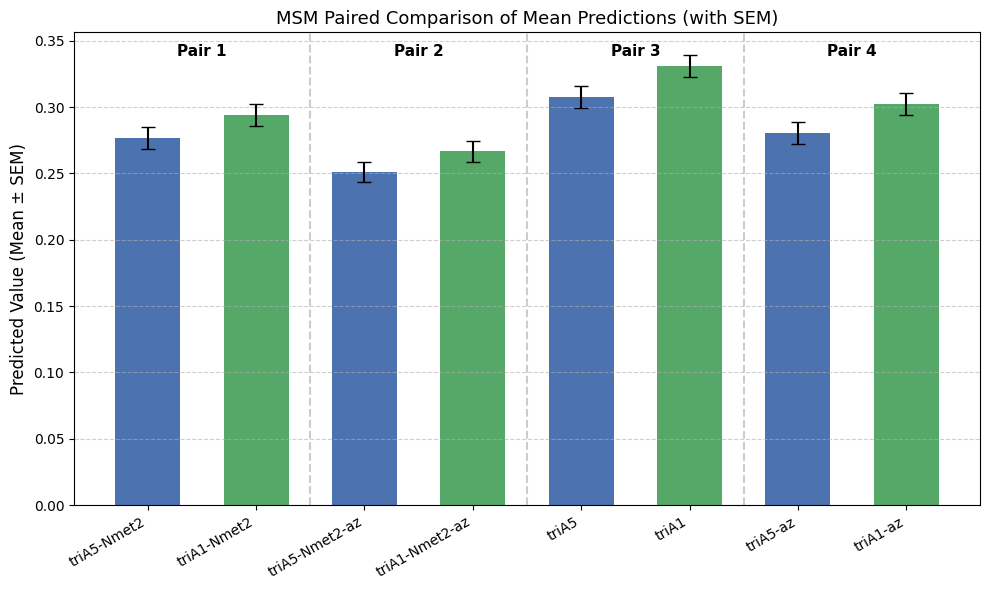

✅ Saved combined paired bar plot as 'MSM_paired_barplot_all_together.png'


In [ ]:
# TRI COMPOUNDS PREDICTION FOR MSM

# ============================================================
# Data
# ============================================================
data = [
    ['triA5-Nmet2', 0.27683523, 0.008060043],
    ['triA5-Nmet2-az', 0.251059916, 0.007783748],
    ['triA5', 0.307346878, 0.008330476],
    ['triA5-az', 0.280427511, 0.00813397],
    ['triA1-Nmet2', 0.293844719, 0.008107873],
    ['triA1-Nmet2-az', 0.266840542, 0.007879563],
    ['triA1', 0.331022641, 0.008315482],
    ['triA1-az', 0.302409617, 0.00821695]
]

df = pd.DataFrame(data, columns=['Compound', 'Mean', 'SEM'])

# ============================================================
# Define pairing
# ============================================================
pairs = [
    ('triA5-Nmet2', 'triA1-Nmet2'),
    ('triA5-Nmet2-az', 'triA1-Nmet2-az'),
    ('triA5', 'triA1'),
    ('triA5-az', 'triA1-az')
]

# Flatten compounds in plotting order
plot_order = [p for pair in pairs for p in pair]
df = df.set_index('Compound').loc[plot_order].reset_index()

# ============================================================
# Plot setup
# ============================================================
plt.style.use('seaborn-v0_8-colorblind')
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(df))
colors = ['#4C72B0', '#55A868'] * 4  # alternating colors for pairs

bars = ax.bar(x, df['Mean'], yerr=df['SEM'], capsize=5, color=colors, width=0.6)
ax.set_xticks(x)
ax.set_xticklabels(df['Compound'], rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Predicted Value (Mean ± SEM)', fontsize=12)
ax.set_title('MSM Paired Comparison of Mean Predictions (with SEM)', fontsize=13)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Add group separation lines
for i in [1.5, 3.5, 5.5]:
    ax.axvline(i, color='gray', linestyle='--', alpha=0.4)

# Add labels for each pair on top
pair_labels = ['Pair 1', 'Pair 2', 'Pair 3', 'Pair 4']
pair_centers = [0.5, 2.5, 4.5, 6.5]
for label, center in zip(pair_labels, pair_centers):
    ax.text(center, df['Mean'].max() + 0.005, label, ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('MSM_paired_barplot_all_together.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved combined paired bar plot as 'MSM_paired_barplot_all_together.png'")



## W COMPOUNDS PREDICTIONS

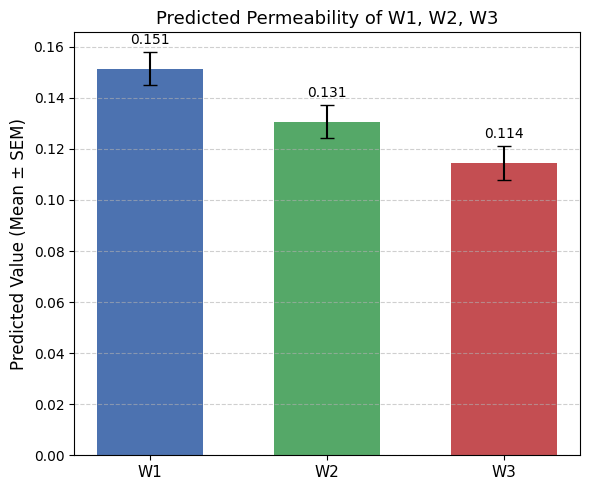

✅ Saved bar plot as 'W1_W2_W3_barplot.png'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Data
# ============================================================
data = [
    ['W1', 0.15130544, 0.006467462],
    ['W2', 0.130680873, 0.006442638],
    ['W3', 0.114487192, 0.006617372]
]

df = pd.DataFrame(data, columns=['Compound', 'Mean', 'SEM'])

# ============================================================
# Plot setup
# ============================================================
plt.style.use('seaborn-v0_8-colorblind')
fig, ax = plt.subplots(figsize=(6, 5))

x = np.arange(len(df))
colors = ['#4C72B0', '#55A868', '#C44E52']  # one color per compound

bars = ax.bar(x, df['Mean'], yerr=df['SEM'], capsize=5, color=colors, width=0.6)
ax.set_xticks(x)
ax.set_xticklabels(df['Compound'], fontsize=11)
ax.set_ylabel('Predicted Value (Mean ± SEM)', fontsize=12)
ax.set_title('Predicted Permeability of W1, W2, W3', fontsize=13)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate bar values
for i, (mean, sem) in enumerate(zip(df['Mean'], df['SEM'])):
    ax.text(i, mean + sem + 0.002, f"{mean:.3f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('W1_W2_W3_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved bar plot as 'W1_W2_W3_barplot.png'")


## JSF compounds prediction plot

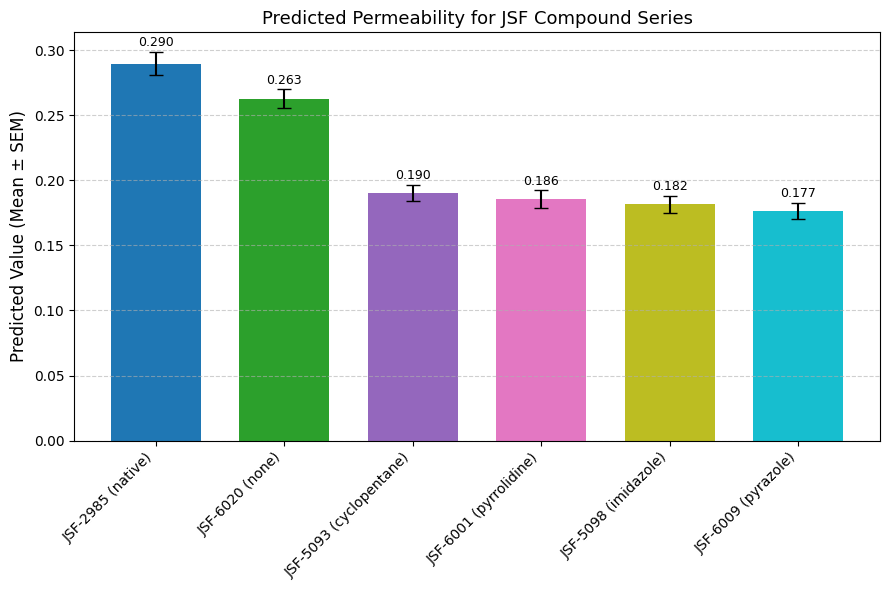

✅ Saved ranked bar plot as 'JSF_compounds_barplot_ranked.png'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Data
# ============================================================
data = [
    ['JSF-6009 (pyrazole)', 0.176556404, 0.006307674],
    ['JSF-5098 (imidazole)', 0.181517719, 0.006436745],
    ['JSF-2985 (native)', 0.289689671, 0.009093694],
    ['JSF-5093 (cyclopentane)', 0.190251074, 0.006511615],
    ['JSF-6001 (pyrrolidine)', 0.185659786, 0.00673631],
    ['JSF-6020 (none)', 0.262869617, 0.007028608]
]

df = pd.DataFrame(data, columns=['Compound', 'Mean', 'SEM'])

# ============================================================
# Sort in descending order of predicted mean
# ============================================================
df = df.sort_values('Mean', ascending=False).reset_index(drop=True)

# ============================================================
# Plot setup
# ============================================================
plt.style.use('seaborn-v0_8-colorblind')
fig, ax = plt.subplots(figsize=(9, 6))

x = np.arange(len(df))
colors = plt.cm.tab10(np.linspace(0, 1, len(df)))  # distinct colors

bars = ax.bar(x, df['Mean'], yerr=df['SEM'], capsize=5, color=colors, width=0.7)
ax.set_xticks(x)
ax.set_xticklabels(df['Compound'], rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Predicted Value (Mean ± SEM)', fontsize=12)
ax.set_title('Predicted Permeability for JSF Compound Series', fontsize=13)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate bar values
for i, (mean, sem) in enumerate(zip(df['Mean'], df['SEM'])):
    ax.text(i, mean + sem + 0.002, f"{mean:.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('JSF_compounds_barplot_ranked.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved ranked bar plot as 'JSF_compounds_barplot_ranked.png'")



# significance test

## w compounds


Processing sheet: Fig4c (W peptides)
Loading training args


/usr/local/lib/python3.12/dist-packages/chemprop/utils.py:473: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vars(torch.load(path, map_location=lambda storage, loc: storage)

Setting molecule featurization parameters to default.
Loading data


3it [00:00, 11335.96it/s]
100%|██████████| 3/3 [00:00<00:00, 15827.56it/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Validating SMILES
Test size = 3
Encoding smiles into a fingerprint vector from 1 models.


...

Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".



100%|██████████| 1/1 [00:03<00:00,  3.23s/it]


Saving predictions to content/1600all_embeddings.csv
Elapsed time = 0:00:04


Predicting 50 models for Fig4c (W peptides): 100%|██████████| 50/50 [00:01<00:00, 45.06it/s]



✅ Saved mean/std workbook and full per-model predictions to tester_w.xlsx_AllModelPredictions.csv


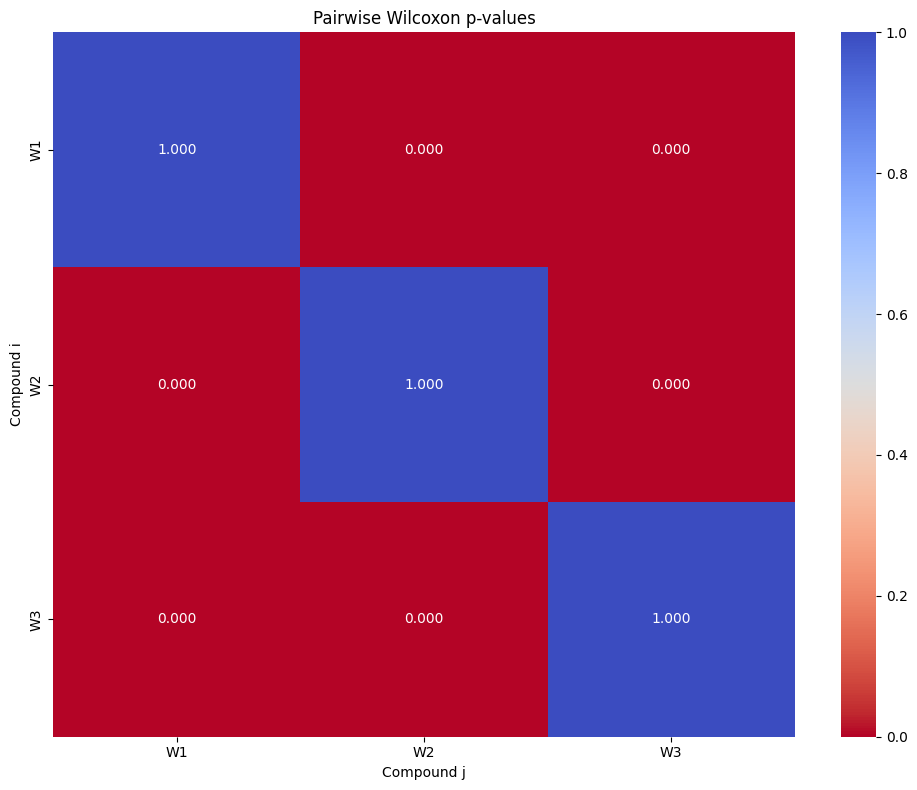

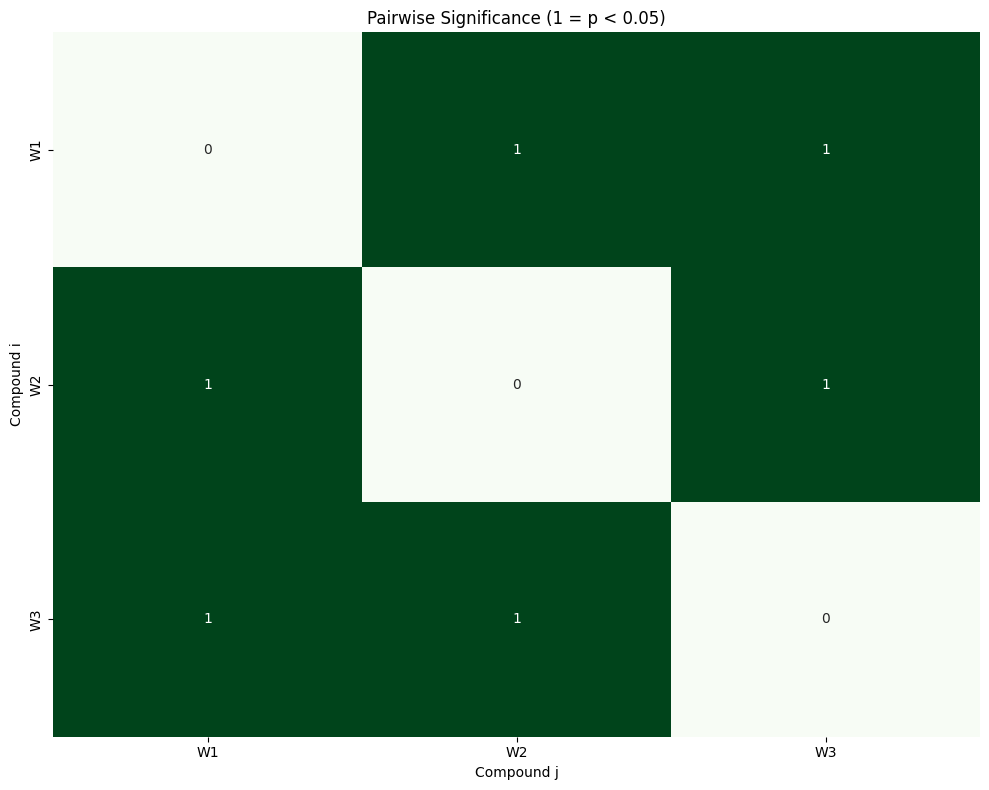


🏆 Dominance-based Rank Order:
  Compound  Significant_Wins  Rank
0       W1                 2     1
1       W2                 2     2
2       W3                 2     3


In [ ]:
from tqdm import tqdm

file_path = 'final_mtb_predictions_kishor_w.xlsx'
sheet_names = ['Fig4c (W peptides)']
output_file = 'tester_w.xlsx'
preds_path = 'content/1600all_embeddings.csv'
smiles_column = 'SMILES'
fingerprint_type = 'MPN'

def process_and_predict_full(file_path, sheet_names, preds_path, checkpoint_dir,
                             smiles_column, fingerprint_type, mlp_list, output_prefix):
    all_preds_long = []   # store all model predictions for stats
    writer = pd.ExcelWriter(f"{output_prefix}_MeanStd.xlsx", engine='openpyxl')

    for sheet in sheet_names:
        print(f"\nProcessing sheet: {sheet}")
        df = pd.read_excel(file_path, sheet_name=sheet)
        csv_name = f"{sheet}.csv"
        df.to_csv(csv_name, index=False)

        # === Chemprop fingerprint generation ===
        args = chemprop.args.FingerprintArgs().parse_args([
            '--test_path', csv_name,
            '--preds_path', preds_path,
            '--checkpoint_dir', checkpoint_dir,
            '--smiles_columns', smiles_column,
            '--fingerprint_type', fingerprint_type
        ])
        chemprop.train.molecule_fingerprint.molecule_fingerprint(args=args)
        preds_df = pd.read_csv(preds_path)
        X_pred = preds_df.iloc[:, 1:]

        # === Predict with all 50 MLPs ===
        all_preds = []
        for seed, mlp in enumerate(tqdm(mlp_list, desc=f"Predicting 50 models for {sheet}")):
            preds = mlp.predict(X_pred)
            all_preds.append(preds)

            # save each model’s predictions in long form
            temp = pd.DataFrame({
                "Sheet": sheet,
                "Compound": df["COMPOUND NAME"],
                "Model_Seed": seed,
                "Prediction": preds
            })
            all_preds_long.append(temp)

        preds_array = np.array(all_preds)
        df['Pred_Mean'] = preds_array.mean(axis=0)
        df['Pred_Std']  = preds_array.std(axis=0)
        df['SEM'] = df['Pred_Std']/np.sqrt(50)
        df.to_excel(writer, sheet_name=sheet[:31], index=False)

    writer.close()
    all_preds_long = pd.concat(all_preds_long, ignore_index=True)
    all_preds_long.to_csv(f"{output_prefix}_AllModelPredictions_msm.csv", index=False)
    print(f"\n✅ Saved mean/std workbook and full per-model predictions to {output_prefix}_AllModelPredictions.csv")
    return all_preds_long

process_and_predict_full(
    file_path, sheet_names, preds_path, checkpoint_dir,
    smiles_column, fingerprint_type, mlp_models, output_file
)

import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# 1️⃣ Load predictions (long format)
# -------------------------------
df = pd.read_csv("tester_w.xlsx_AllModelPredictions_msm.csv")  # columns: Model_Seed, Sheet, Compound, Prediction

# -------------------------------
# 2️⃣ Pivot to wide format
# -------------------------------
df_wide = df.pivot(index='Model_Seed', columns='Compound', values='Prediction')

compounds = df_wide.columns.tolist()
n = len(compounds)

# -------------------------------
# 3️⃣ Pairwise Wilcoxon signed-rank tests (p-values)
# -------------------------------
p_matrix = np.ones((n, n))
for i in range(n):
    for j in range(i+1, n):
        stat, p = wilcoxon(df_wide.iloc[:, i], df_wide.iloc[:, j])
        p_matrix[i, j] = p
        p_matrix[j, i] = p  # symmetric

p_df = pd.DataFrame(p_matrix, index=compounds, columns=compounds)

# -------------------------------
# 4️⃣ Heatmap of p-values
# -------------------------------
plt.figure(figsize=(10,8))
sns.heatmap(p_df, annot=True, fmt=".3f", cmap="coolwarm_r", cbar=True)
plt.title("Pairwise Wilcoxon p-values")
plt.ylabel("Compound i")
plt.xlabel("Compound j")
plt.tight_layout()
plt.show()

# -------------------------------
# 5️⃣ Binary significance matrix
# -------------------------------
sig_matrix = (p_df < 0.05).astype(int)

plt.figure(figsize=(10,8))
sns.heatmap(sig_matrix, annot=True, cmap="Greens", cbar=False)
plt.title("Pairwise Significance (1 = p < 0.05)")
plt.ylabel("Compound i")
plt.xlabel("Compound j")
plt.tight_layout()
plt.show()

# -------------------------------
# 6️⃣ Dominance-based ranking
# -------------------------------
dominance_scores = sig_matrix.sum(axis=1).sort_values(ascending=False)
rank_df = pd.DataFrame({
    'Compound': dominance_scores.index,
    'Significant_Wins': dominance_scores.values,
    'Rank': range(1, n+1)
})

print("\n🏆 Dominance-based Rank Order:")
print(rank_df)


## kishor compounds

In [ ]:
## for w compounds
for i in range(n):
    for j in range(i+1, n):
        stat, p = wilcoxon(df_wide.iloc[:, i], df_wide.iloc[:, j])
        p_matrix[i, j] = p
        p_matrix[j, i] = p

        # 🔥 print raw p-values in scientific notation
        print(f"{compounds[i]} vs {compounds[j]}  ->  p = {p:.16g}")


W1 vs W2  ->  p = 1.243449787580175e-14
W1 vs W3  ->  p = 1.77635683940025e-14
W2 vs W3  ->  p = 3.002043058586423e-13


# MSM Cheminformatics

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

file = pd.read_excel('cddVisualizationExport_Mon Nov 10 2025.xlsx')
logD = file['Log D (CDD calculated)']
logS = file['Log S (CDD calculated)']

descriptors_df = pd.read_csv('msm_descriptors_with_smiles.csv').iloc[:,1::]
descriptors_df

,Smiles,HBA,HBD,HBA+HBD,NumRings,RTB,NumAmideBonds,Globularity,PBF,TPSA,...,fmf,QED,HAC,NumRingsFused,unique_HBAD,max_ring_size,n_chiral_centers,fcsp3_bm,formal_charge,abs_charge
0,O=C1NC(CCC1(CC)C2=CC=C(N=[N+]=[N-])C=C2)=O,3,1,4,2,4,2,0.577116,1.177200,94.93,...,0.736842,0.390229,19,2,4,6,1,0.272727,0,0
1,OC([C@@H](NC(OC(C)(C)C)=O)CC1=CC=C(N=[N+]=[N-]...,5,2,7,1,5,1,0.524887,1.392357,124.39,...,0.272727,0.492094,22,1,6,6,1,0.000000,0,0
2,O[C@H]1[C@@H](CO)O[C@@H](OC2=CC=C(N=[N+]=[N-])...,7,4,11,2,8,0,0.568013,1.208233,148.14,...,0.619048,0.343588,21,2,7,6,5,0.454545,0,0
3,COC1=CC(CCN=[N+]=[N-])=CC=C1,2,0,2,1,5,0,0.613439,1.460114,57.99,...,0.461538,0.395775,13,1,2,6,0,0.000000,0,0
4,C[C@@H](COC1=C2C(C3=O)=CC(F)=C1C4(N=[N+]=[N-])...,6,1,7,4,4,0,0.557084,1.237077,115.60,...,0.680000,0.522704,25,2,6,6,1,0.357143,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1559,COC(=O)C1=C(N=[N+]=[N-])N(C)C=2C=CC=CC12,4,0,4,2,4,0,0.614757,1.191817,79.99,...,0.529412,0.343781,17,1,4,6,0,0.000000,0,0
1560,CC(C)(C)OC(N[C@@H](CC1=CC=C(N=[N+]=[N-])C=C1)C...,5,2,7,1,5,1,0.524734,1.147860,124.39,...,0.272727,0.492094,22,1,6,6,1,0.000000,0,0
1561,CC=1C=CC=C2NC=C(C(=O)CN3CCC(CC3)C(=O)N[C@@H]4C...,7,3,10,4,7,1,0.509116,1.152017,160.49,...,0.702703,0.227630,37,3,9,6,2,0.500000,0,0
1562,OC(=O)C(CC1=CNC=2C=CC=CC12)NC(=O)[C@H]3C[C@@H]...,4,3,7,3,6,1,0.522731,1.373519,130.95,...,0.750000,0.427285,24,2,6,6,1,0.400000,0,0


In [ ]:
from rdkit import Chem
import pandas as pd
import numpy as np

siegrist = pd.read_excel('20240813_comprehensive_data(2).xlsx',
                         sheet_name = 'smiles_react_perm_380')
siegrist.head()



df_msm_380 = pd.DataFrame({
    'Smiles': siegrist['Smile'],
    'MSM Standardized Residuals': siegrist['msm_resid_std']
})
siegrist



# Filter invalid SMILES strings
valid_smiles = []
invalid_indices = []
for i, smile in enumerate(df_msm_380['Smiles']):
    mol = Chem.MolFromSmiles(smile)
    if mol is not None:
        valid_smiles.append(smile)
    else:
        invalid_indices.append(i)

# Remove invalid entries from df
df_msm_380 = df_msm_380.drop(invalid_indices).reset_index(drop=True)

# Display the last 300 rows
print(df_msm_380.shape)


y_msm380 = df_msm_380['MSM Standardized Residuals']

# 1200
siegrist = pd.read_excel('20240813_comprehensive_data(2).xlsx',
                         sheet_name = 'smiles_react_perm_1200')
siegrist.head()


df_msm_1200 = pd.DataFrame({
    'Smiles': siegrist['Smile'],
    'MSM Standardized Residuals': siegrist['msm_resid_std']
})
siegrist

df_msm_1200.dropna(axis=0, inplace=True)

# Filter invalid SMILES strings
valid_smiles = []
invalid_indices = []
for i, smile in enumerate(df_msm_1200['Smiles']):
    mol = Chem.MolFromSmiles(smile)
    if mol is not None:
        valid_smiles.append(smile)
    else:
        invalid_indices.append(i)

# Remove invalid entries from df
df_msm_1200 = df_msm_1200.drop(invalid_indices).reset_index(drop=True)

# Display the last 300 rows
print(df_msm_1200.shape)


y_mtb1200 = df_msm_1200['MSM Standardized Residuals']


# 1519




df_msm_1519 = pd.concat([df_msm_1200, df_msm_380], axis=0)
df_msm_1519

df_msm_1519.dropna(axis=0, inplace=True)

# Filter invalid SMILES strings
valid_smiles = []
invalid_indices = []
for i, smile in enumerate(df_msm_1519['Smiles']):
    mol = Chem.MolFromSmiles(smile)
    if mol is not None:
        valid_smiles.append(smile)
    else:
        invalid_indices.append(i)




y_msm1519 = df_msm_1519['MSM Standardized Residuals']



sieg_40 = pd.read_excel('20240813_comprehensive_data(2).xlsx',
                         sheet_name = 'smiles_react_perm_40')

sieg_40

df_msm_40 = pd.DataFrame({
    'Smiles': sieg_40['Smile'],
    'MSM Standardized Residuals': sieg_40['mtb_resid_std']
})

df_msm_1600  = pd.concat([df_msm_1519, df_msm_40], axis=0)
df_msm_1600

df_msm_1600.dropna(axis=0, inplace=True)





df_msm_1600.dropna(axis=0, inplace=True)

# Filter invalid SMILES strings
valid_smiles = []
invalid_indices = []
for i, smile in enumerate(df_msm_1600['Smiles']):
    mol = Chem.MolFromSmiles(smile)
    if mol is not None:
        valid_smiles.append(smile)
    else:
        invalid_indices.append(i)

# Remove invalid entries from df
df_msm_1600 = df_msm_1600.drop(invalid_indices).reset_index(drop=True)

# Display the last 300 rows
print(df_msm_1600.shape)


y_msm1600 = df_msm_1600['MSM Standardized Residuals']


smiles = df_msm_1600.Smiles
msm = df_msm_1600['MSM Standardized Residuals']

descriptors = descriptors_df.iloc[:,1::]
descriptors_ = pd.concat([descriptors, logD,logS], axis=1)

(376, 2)
(1149, 2)
(1564, 2)


In [ ]:
def scaffold_correlation_analysis_separate(smiles, descriptors, msm, output_prefix="scaffold_correlation_separate"):
    from rdkit import Chem
    from rdkit.Chem import PandasTools
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd
    import os

    # Define scaffold SMARTS patterns
    scaffolds_smarts = {
        "CYCLOHEXANE": "C1CCCCC1",
        "CYCLOPENTANE": "C1CCCC1",
        "PIPERIDINE": "C1CCNCC1",
        "PYRROLIDINE": "C1CCNC1",
        "PYRAZOLE": "n1nccc1",
        "IMIDAZOLE": "c1cncn1",
        "INDOLE": "c1c[nH]c2c1cccc2",
        "INDAZOLE": "c1ccc2[nH]ncc2c1",
        "PYRIDINE": "c1ccncc1",
        "PYRIMIDINE": "c1cncnc1",
        "PYRAZINE": "c1cnccn1",
        "QUINOLINE": "c1ccc2ncccc2c1",
        "BENZENE": "c1ccccc1",
        "NAPHTHALENE": "c1ccc2ccccc2c1",
        "FURAN": "c1ccoc1",
        "TETRAHYDROFURAN": "C1COCC1",
        "TETRAHYDROPYRAN": "C1CCOCC1",
        "THIOPHENE": "c1ccsc1",
    }

    os.makedirs(output_prefix, exist_ok=True)

    # ✅ Rename "Log S (CDD calculated)" and "Log D (CDD calculated)" to "logS" and "logD"
    descriptors = descriptors.rename(columns={
        "Log S (CDD calculated)": "logS",
        "Log D (CDD calculated)": "logD"
    })

    # ✅ Desired descriptor order with simplified names
    desired_order = [
        'Globularity', 'Csp3', 'fcsp3_bm', 'fmf', 'NumRings', 'logS',
        'n_chiral_centers', 'abs_charge', 'formal_charge', 'logP', 'logD',
        'PBF', 'max_ring_size', 'NumFusedRings', 'NumAmideBonds', 'HBA',
        'RTB', 'MR', 'MW', 'HAC', 'unique_HBAD', 'TPSA', 'HBD', 'HBA+HBD', 'QED'
    ]

    extra_indole_compounds = pd.DataFrame({
        'Smiles': [
            "CCN(C1=C2C=CC=C1)C(C=C3)=C2C=C3N=[N+]=[N-]",
            "[N-]=[N+]=NCCC1=CNC2=C1C=CC=C2",
            "[N-]=[N+]=NCCC1=CNC=2C=CC=CC12"
        ],
        'MSM Standardized Residuals': [-1.42277, -1.80378, -2.15202]
    })

    extra_indazole_compounds = pd.DataFrame({
        'Smiles': ['CN(N=C1C=C2)C=C1C=C2N=[N+]=[N-]',
    'O=C(OC(C)(C)C)N1N=CC2=CC(N=[N+]=[N-])=CC=C21',
    '[N-]=[N+]=NCC1=CC2=CNN=C2C=C1'],
        'MSM Standardized Residuals':[-1.92718,
                                      -1.47558,
                                      -2.20251]
    })


    # ✅ Reorder descriptor columns
    descriptors = descriptors[[col for col in desired_order if col in descriptors.columns]]

    # # Merge smiles, descriptors and bacterial labels
    dataset = pd.concat([smiles, descriptors, msm], axis=1)
    # PandasTools.AddMoleculeColumnToFrame(dataset, smilesCol='Smiles', molCol='Molecule')

    extra_compounds = pd.concat([extra_indole_compounds, extra_indazole_compounds], ignore_index=True)
    # Add missing descriptor columns as NaN (so concatenation works cleanly)
    for col in dataset.columns:
        if col not in extra_compounds.columns:
            extra_compounds[col] = None

    # Ensure consistent column order
    extra_compounds = extra_compounds[dataset.columns]

    # Append new compounds to the dataset
    dataset = pd.concat([dataset, extra_compounds], ignore_index=True)

    # --- Add RDKit Molecule column ---
    PandasTools.AddMoleculeColumnToFrame(dataset, smilesCol='Smiles', molCol='Molecule')


    scaffold_dataframes = {}
    scaffold_counts = {}

    for scaffold_name, scaffold_smarts in scaffolds_smarts.items():
        scaffold_mol = Chem.MolFromSmarts(scaffold_smarts)
        df_scaffold = dataset[dataset['Molecule'].apply(lambda mol: mol.HasSubstructMatch(scaffold_mol))]
        scaffold_dataframes[scaffold_name] = df_scaffold
        scaffold_counts[scaffold_name] = len(df_scaffold)

    # Add "no rings" and full dataset
    df_no_rings = dataset[dataset['Molecule'].apply(lambda mol: mol.GetRingInfo().NumRings() == 0)]
    scaffold_dataframes['NO_RINGS'] = df_no_rings
    scaffold_counts['NO_RINGS'] = len(df_no_rings)

    scaffold_dataframes['WHOLE_DATASET'] = dataset
    scaffold_counts['WHOLE_DATASET'] = len(dataset)

    # Dictionary for bacterial datasets
    bacteria_data = {"Msm": msm}
    all_correlation_matrices = {}

    for bug, label_values in bacteria_data.items():
        # Combine dataset with bacterial labels
        dataset_with_label = pd.concat([dataset, label_values], axis=1)

        correlation_results = {}

        for scaffold_name, scaffold_df in scaffold_dataframes.items():
            if not scaffold_df.empty:
                scaffold_with_label = pd.concat(
                    [scaffold_df.drop(columns=["Molecule"]),
                     label_values.loc[scaffold_df.index]],
                    axis=1
                )
                scaffold_with_label = scaffold_with_label.apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all')

                if scaffold_with_label.empty or scaffold_with_label.shape[1] <= 1:
                    continue

                label_column = label_values.columns[0] if isinstance(label_values, pd.DataFrame) else label_values.name
                correlation_matrix = scaffold_with_label.corr()
                correlation_with_label = (
                    correlation_matrix[label_column]
                    .drop(labels=[label_column])
                    .fillna(0)
                    .sort_values(ascending=False)
                )

                correlation_results[scaffold_name] = correlation_with_label

        correlation_matrix = pd.DataFrame.from_dict(correlation_results, orient='index')
        all_correlation_matrices[bug] = correlation_matrix

    # Fix scaffold (row) order
    common_index = list(scaffold_dataframes.keys())
    for bug in all_correlation_matrices:
        all_correlation_matrices[bug] = all_correlation_matrices[bug].reindex(index=common_index)

    # ✅ Plotting separate heatmaps with enforced descriptor order and fixed color scale
    for bug, corr_matrix in all_correlation_matrices.items():
        if corr_matrix.isnull().all().all():
            print(f"No valid data for {bug}, skipping plot.")
            continue

        # ✅ Enforce descriptor order for consistent x-axis
        corr_matrix = corr_matrix.reindex(columns=[col for col in desired_order if col in corr_matrix.columns])

        scaffold_labels = [f"{name} ({scaffold_counts[name]})" for name in corr_matrix.index]
        corr_matrix.index = scaffold_labels

        plt.figure(figsize=(14, 9))
        sns.heatmap(
            corr_matrix,
            annot=False,
            cmap='coolwarm',
            vmin=-1, vmax=1,  # ✅ Fixed color scale from -1 to 1
            cbar_kws={'label': f'Correlation with {bug}'},
            linewidths=0.5
        )
        plt.title('Correlation Heatmap: MSM Standardized Residuals')
        plt.xlabel('Descriptors')
        plt.ylabel('Scaffolds')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()

        plt.savefig(f"{output_prefix}/{bug}_heatmap.png", dpi=300, bbox_inches='tight')
        print(f"✅ Saved {bug} heatmap with fixed color scale (-1 to 1).")
        plt.show()
        plt.close()

scaffold_correlation_analysis_separate(smiles, descriptors_, msm, output_prefix="scaffold_correlation_separate")



/tmp/ipython-input-2190696581.py:83: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dataset = pd.concat([dataset, extra_compounds], ignore_index=True)


TypeError: DataFrame.sort_values() missing 1 required positional argument: 'by'

In [ ]:
smiles

,Smiles
0,O=C1NC(CCC1(CC)C2=CC=C(N=[N+]=[N-])C=C2)=O
1,OC([C@@H](NC(OC(C)(C)C)=O)CC1=CC=C(N=[N+]=[N-]...
2,O[C@H]1[C@@H](CO)O[C@@H](OC2=CC=C(N=[N+]=[N-])...
3,COC1=CC(CCN=[N+]=[N-])=CC=C1
4,C[C@@H](COC1=C2C(C3=O)=CC(F)=C1C4(N=[N+]=[N-])...
...,...
1559,COC(=O)C1=C(N=[N+]=[N-])N(C)C=2C=CC=CC12
1560,CC(C)(C)OC(N[C@@H](CC1=CC=C(N=[N+]=[N-])C=C1)C...
1561,CC=1C=CC=C2NC=C(C(=O)CN3CCC(CC3)C(=O)N[C@@H]4C...
1562,OC(=O)C(CC1=CNC=2C=CC=CC12)NC(=O)[C@H]3C[C@@H]...


/tmp/ipython-input-3494718730.py:78: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dataset = pd.concat([dataset, extra_compounds], ignore_index=True)


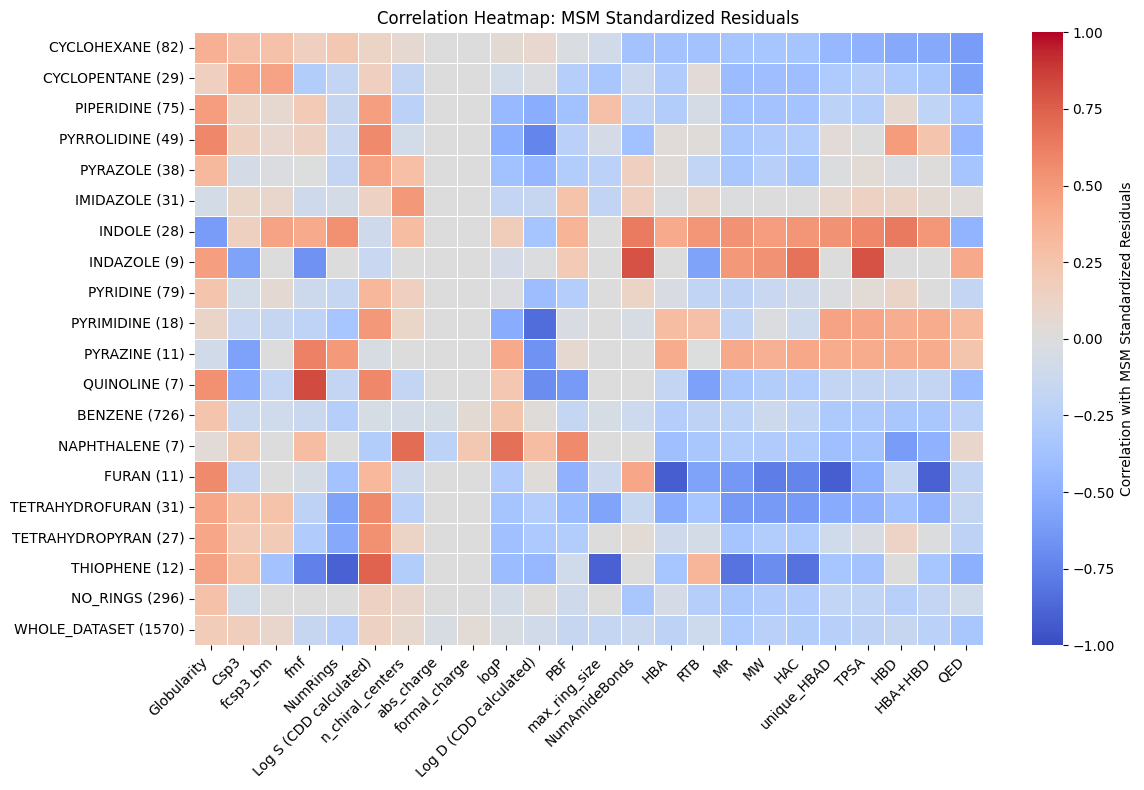

In [ ]:
from rdkit import Chem
from rdkit.Chem import PandasTools
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


smiles_series = smiles["Smiles"] if isinstance(smiles, pd.DataFrame) else smiles
msm_label = msm["MSM Standardized Residuals"] if isinstance(msm, pd.DataFrame) else msm

# Build initial dataset
dataset = pd.concat([smiles_series, descriptors_, msm_label], axis=1)
dataset.columns = list(descriptors_.columns.insert(0, "Smiles")) + ["MSM Standardized Residuals"]


# ---------------------------------------------------------
# Scaffold SMARTS patterns
# ---------------------------------------------------------
scaffolds_smarts = {
    "CYCLOHEXANE": "C1CCCCC1",
    "CYCLOPENTANE": "C1CCCC1",
    "PIPERIDINE": "C1CCNCC1",
    "PYRROLIDINE": "C1CCNC1",
    "PYRAZOLE": "n1nccc1",
    "IMIDAZOLE": "c1cncn1",
    "INDOLE": "c1c[nH]c2c1cccc2",
    "INDAZOLE": "c1ccc2[nH]ncc2c1",
    "PYRIDINE": "c1ccncc1",
    "PYRIMIDINE": "c1cncnc1",
    "PYRAZINE": "c1cnccn1",
    "QUINOLINE": "c1ccc2ncccc2c1",
    "BENZENE": "c1ccccc1",
    "NAPHTHALENE": "c1ccc2ccccc2c1",
    "FURAN": "c1ccoc1",
    "TETRAHYDROFURAN": "C1COCC1",
    "TETRAHYDROPYRAN": "C1CCOCC1",
    "THIOPHENE": "c1ccsc1",
}

descriptor_order = [
        'Globularity', 'Csp3', 'fcsp3_bm', 'fmf', 'NumRings', 'Log S (CDD calculated)',
        'n_chiral_centers', 'abs_charge', 'formal_charge',	'logP', 'Log D (CDD calculated)',
        'PBF', 'max_ring_size', 'NumFusedRings', 'NumAmideBonds', 'HBA',
        'RTB', 'MR', 'MW', 'HAC', 'unique_HBAD', 'TPSA', 'HBD', 'HBA+HBD', 'QED']

# ---------------------------------------------------------
# Add extra indole & indazole compounds
# ---------------------------------------------------------
extra_indole = pd.DataFrame({
    "Smiles": [
        "CCN(C1=C2C=CC=C1)C(C=C3)=C2C=C3N=[N+]=[N-]",
        "[N-]=[N+]=NCCC1=CNC2=C1C=CC=C2",
        "[N-]=[N+]=NCCC1=CNC=2C=CC=CC12",
    ],
    "MSM Standardized Residuals": [-1.023731, -2.136745, np.mean([-1.023731, -2.136745])] #last not found but not significant contribution
})

extra_indazole = pd.DataFrame({
    "Smiles": [
        "CN(N=C1C=C2)C=C1C=C2N=[N+]=[N-]",
        "O=C(OC(C)(C)C)N1N=CC2=CC(N=[N+]=[N-])=CC=C21",
        "[N-]=[N+]=NCC1=CC2=CNN=C2C=C1",
    ],
    "MSM Standardized Residuals": [ -1.927184, -1.475584, -2.202506]
})

extra_compounds = pd.concat([extra_indole, extra_indazole], ignore_index=True)

# Add any missing descriptor columns as NaN
for col in dataset.columns:
    if col not in extra_compounds.columns:
        extra_compounds[col] = None

# Match column order
extra_compounds = extra_compounds[dataset.columns]

# Append to dataset
dataset = pd.concat([dataset, extra_compounds], ignore_index=True)

# ---------------------------------------------------------
# Add RDKit molecule column
# ---------------------------------------------------------
dataset["Smiles"] = dataset["Smiles"].astype(str)  # prevent float SMILES
PandasTools.AddMoleculeColumnToFrame(dataset, smilesCol="Smiles", molCol="Molecule")

# ---------------------------------------------------------
# Build scaffold groups
# ---------------------------------------------------------
scaffold_dataframes = {}
scaffold_counts = {}

for name, smarts in scaffolds_smarts.items():
    pattern = Chem.MolFromSmarts(smarts)
    df = dataset[dataset["Molecule"].apply(
        lambda m: m is not None and m.HasSubstructMatch(pattern)
    )]
    scaffold_dataframes[name] = df
    scaffold_counts[name] = len(df)

# NO RINGS
df_no_rings = dataset[dataset["Molecule"].apply(
    lambda m: m is not None and m.GetRingInfo().NumRings() == 0
)]
scaffold_dataframes["NO_RINGS"] = df_no_rings
scaffold_counts["NO_RINGS"] = len(df_no_rings)

# WHOLE DATASET
scaffold_dataframes["WHOLE_DATASET"] = dataset
scaffold_counts["WHOLE_DATASET"] = len(dataset)

scaffold_dataframes["INDAZOLE"] = pd.concat([
    scaffold_dataframes["INDAZOLE"],
    extra_indazole
], ignore_index=True)

# Fix count
scaffold_counts["INDAZOLE"] = len(scaffold_dataframes["INDAZOLE"])


# ---------------------------------------------------------
# Correlations to MSM
# ---------------------------------------------------------
correlation_results = {}

for name, sdf in scaffold_dataframes.items():
    if sdf.empty:
        continue

    numeric_df = sdf.drop(columns=["Smiles", "Molecule"], errors="ignore")
    numeric_df = numeric_df.apply(pd.to_numeric, errors="coerce")
    numeric_df = numeric_df.dropna(axis=1, how="all")

    if "MSM Standardized Residuals" not in numeric_df.columns:
        continue

    corr = numeric_df.corr()
    corr_vec = (
        corr["MSM Standardized Residuals"]
        .drop(labels=["MSM Standardized Residuals"], errors="ignore")
        .fillna(0)
        .sort_values(ascending=False)
    )

    correlation_results[name] = corr_vec

# ---------------------------------------------------------
# Build correlation matrix for heatmap
# ---------------------------------------------------------
corr_matrix = pd.DataFrame.from_dict(correlation_results, orient="index")
corr_matrix.index = [
    f"{name} ({scaffold_counts[name]})" for name in corr_matrix.index
]
corr_matrix = corr_matrix.reindex(columns=[c for c in descriptor_order if c in corr_matrix.columns])

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Correlation with MSM Standardized Residuals"},
)
plt.xticks(rotation=45, ha="right")
plt.title("Correlation Heatmap: MSM Standardized Residuals")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Save Excel
# ---------------------------------------------------------
with pd.ExcelWriter("scaffold_correlations_MSM.xlsx") as writer:
    for name, corr_vec in correlation_results.items():
        corr_vec.to_excel(writer, sheet_name=name)


,Smiles,HBA,HBD,HBA+HBD,NumRings,RTB,NumAmideBonds,Globularity,PBF,TPSA,...,unique_HBAD,max_ring_size,n_chiral_centers,fcsp3_bm,formal_charge,abs_charge,Log D (CDD calculated),Log S (CDD calculated),MSM Standardized Residuals,Molecule
0,O=C1NC(CCC1(CC)C2=CC=C(N=[N+]=[N-])C=C2)=O,3,1,4,2,4,2,0.577116,1.177200,94.93,...,4,6,1,0.272727,0,0,0.7,-2.1,0.492247,
1,OC([C@@H](NC(OC(C)(C)C)=O)CC1=CC=C(N=[N+]=[N-]...,5,2,7,1,5,1,0.524887,1.392357,124.39,...,6,6,1,0.000000,0,0,-0.7,-2.2,0.730831,
2,O[C@H]1[C@@H](CO)O[C@@H](OC2=CC=C(N=[N+]=[N-])...,7,4,11,2,8,0,0.568013,1.208233,148.14,...,7,6,5,0.454545,0,0,-1.4,-0.8,0.646756,
3,COC1=CC(CCN=[N+]=[N-])=CC=C1,2,0,2,1,5,0,0.613439,1.460114,57.99,...,2,6,0,0.000000,0,0,1.8,-3.1,0.742640,
4,C[C@@H](COC1=C2C(C3=O)=CC(F)=C1C4(N=[N+]=[N-])...,6,1,7,4,4,0,0.557084,1.237077,115.60,...,6,6,1,0.357143,0,0,0.7,-3.0,0.245381,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1565,[N-]=[N+]=NCCC1=CNC2=C1C=CC=C2,None,None,None,None,None,None,NaN,NaN,NaN,...,None,None,None,NaN,None,None,NaN,NaN,-2.136745,
1566,[N-]=[N+]=NCCC1=CNC=2C=CC=CC12,None,None,None,None,None,None,NaN,NaN,NaN,...,None,None,None,NaN,None,None,NaN,NaN,-1.580238,
1567,CN(N=C1C=C2)C=C1C=C2N=[N+]=[N-],None,None,None,None,None,None,NaN,NaN,NaN,...,None,None,None,NaN,None,None,NaN,NaN,-1.927184,
1568,O=C(OC(C)(C)C)N1N=CC2=CC(N=[N+]=[N-])=CC=C21,None,None,None,None,None,None,NaN,NaN,NaN,...,None,None,None,NaN,None,None,NaN,NaN,-1.475584,

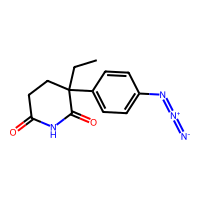
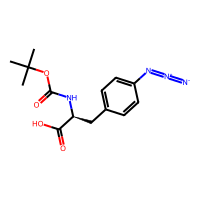
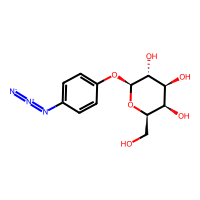
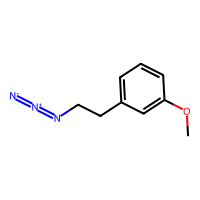
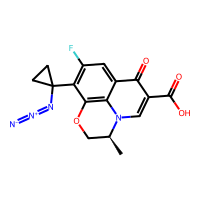
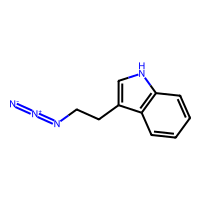
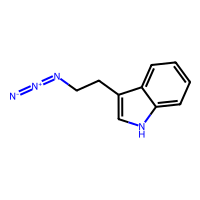
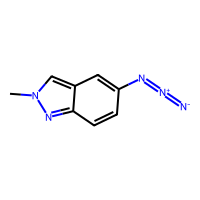
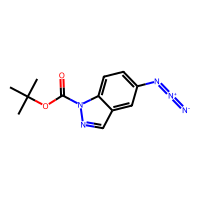
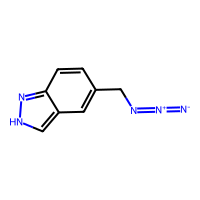

In [ ]:
dataset

Log D (CDD calculated)	Log S (CDD calculated)

In [ ]:
from rdkit import Chem
from rdkit.Chem import PandasTools
import pandas as pd

# Load your full dataset
df = pd.read_excel('20240813_comprehensive_data(2).xlsx')

# Add molecule column if not already present
if "Molecule" not in df.columns:
    df["Smile"] = df["Smile"].astype(str)
    PandasTools.AddMoleculeColumnToFrame(df, smilesCol="Smile", molCol="Molecule")

# --- Define INDAZOLE SMARTS ---
indazole_smarts = Chem.MolFromSmarts("c1ccc2[nH]ncc2c1")  # standard indazole scaffold

# --- Subset indazole compounds ---
indazole_df = df[df["Molecule"].apply(
    lambda m: m is not None and m.HasSubstructMatch(indazole_smarts)
)]

# --- Keep only relevant columns ---
indazole_compare = indazole_df[["Smile", "msm_perm", "mtb_perm"]]

print("\n✅ INDAZOLES (MSM vs MTB):")
print(indazole_compare)



✅ INDAZOLES (MSM vs MTB):
                                Smile  msm_perm  mtb_perm
730     [N-]=[N+]=NCC1=C2NN=CC2=CC=C1  0.071299  0.400023
819  BrC1=CC=C(NN=C2N=[N+]=[N-])C2=C1  0.729324  0.740030


In [ ]:
import pandas as pd

# Load your full dataset
df = pd.read_excel('20240813_comprehensive_data(2).xlsx')

# Extract columns
real_smiles = df['Smile'].astype(str)
real_msm = df['msm_resid_std']

# Mergeable lookup table
lookup = pd.DataFrame({
    "Smiles": real_smiles,
    "Real_MSM": real_msm
})

# Function to update residuals for a given extra-compound dataframe
def update_residuals(extra_df, lookup_df):
    extra_df["Smiles"] = extra_df["Smiles"].astype(str)

    # Merge on SMILES
    merged = extra_df.merge(lookup_df, on="Smiles", how="left")

    # Identify missing matches
    missing = merged[merged["Real_MSM"].isna()]
    if not missing.empty:
        print("\n⚠️ WARNING: These SMILES were NOT found in the real dataset:")
        print(missing["Smiles"].tolist())

    # Replace placeholder residuals with real ones
    extra_df["MSM Standardized Residuals"] = merged["Real_MSM"]

    return extra_df

# --- Update extra indole and indazole ---
extra_indole = update_residuals(extra_indole, lookup)
extra_indazole = update_residuals(extra_indazole, lookup)

print("\n✅ Updated extra_indole:")
print(extra_indole)

print("\n✅ Updated extra_indazole:")
print(extra_indazole)



⚠️ WARNING: These SMILES were NOT found in the real dataset:
['[N-]=[N+]=NCCC1=CNC=2C=CC=CC12']

✅ Updated extra_indole:
                                       Smiles  MSM Standardized Residuals
0  CCN(C1=C2C=CC=C1)C(C=C3)=C2C=C3N=[N+]=[N-]                   -1.023731
1              [N-]=[N+]=NCCC1=CNC2=C1C=CC=C2                   -2.136745
2              [N-]=[N+]=NCCC1=CNC=2C=CC=CC12                         NaN

✅ Updated extra_indazole:
                                         Smiles  MSM Standardized Residuals
0               CN(N=C1C=C2)C=C1C=C2N=[N+]=[N-]                   -1.927184
1  O=C(OC(C)(C)C)N1N=CC2=CC(N=[N+]=[N-])=CC=C21                   -1.475584
2                 [N-]=[N+]=NCC1=CC2=CNN=C2C=C1                   -2.202506


In [ ]:
df

,Smile,logReact,mtb_perm,msm_perm,mtb_resid_std,msm_resid_std
0,O=C1NC(CCC1(CC)C2=CC=C(N=[N+]=[N-])C=C2)=O,-1.091612,0.931106,0.492247,-0.419953,-0.639047
1,OC([C@@H](NC(OC(C)(C)C)=O)CC1=CC=C(N=[N+]=[N-]...,-0.450019,0.951983,0.730831,0.556694,0.440240
2,O[C@H]1[C@@H](CO)O[C@@H](OC2=CC=C(N=[N+]=[N-])...,-0.437056,0.850383,0.646756,0.364465,0.266734
3,COC1=CC(CCN=[N+]=[N-])=CC=C1,-0.302619,1.182123,0.742640,1.249244,0.593714
4,C[C@@H](COC1=C2C(C3=O)=CC(F)=C1C4(N=[N+]=[N-])...,-1.014353,0.805287,0.245381,-0.568972,-1.114593
...,...,...,...,...,...,...
1144,[N-]=[N+]=NC1=CC=CC2=C1OCCO2,-1.186041,0.951864,0.274657,-0.514184,-1.198812
1145,CC(N=[N+]=[N-])C1=CC=NC=C1,-0.689622,0.964068,0.408149,0.233269,-0.476025
1146,CC1=NC(C)=C(CN=[N+]=[N-])S1,-1.234136,0.716610,0.109576,-1.072908,-1.603122
1147,CN(CC1=CC=C(CSCCN=[N+]=[N-])O1)C,-1.610763,0.516614,0.070927,-2.036269,-2.013889
